In [1]:
import os
from Scope.Read_Write import load_binary

In [2]:
## In this tutorial, we will discuss the STATE class. What is it exactly, and how it interacts with SPECIES and COMPUTATIONS.
## The STATE class is probably the least-intuitive class, so lets see a practical example.

In [3]:
## Loads the System object from a binary file, provided in the tutorial folder
sys = load_binary(os.path.abspath('.')+'/Sources/ABITEM.npy')
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE SCO-System Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Name                  = ABITEM
 Source Path           = /data/ucsscms/svela/4-Merged/ABITEM/
 Calculations Path     = /home/svela/SCOPE/Test_V1/Calcs/ABITEM/
 System File Path      = /home/svela/SCOPE/Test_V1/Systems/ABITEM/

 # of Sources          = 6
     idx, type, name, formula               
     0: cell ABITEM01 H104-C92-N24-O4-S8-Fe4 
     1: cell ABITEM H104-C92-N24-O4-S8-Fe4 
     2: cell ref_hs_cell H104-C92-N24-O4-S8-Fe4 
     3: cell ref_ls_cell H104-C92-N24-O4-S8-Fe4 
     4: specie ref_hs_mol H18-C20-N6-S2-Fe 
     5: specie ref_ls_mol H18-C20-N6-S2-Fe 




In [4]:
## Sources can be selected using the find_source function, and using the source name
found, source = sys.find_source("ref_hs_mol")
print(found)
print(source)

True
--------------------------------------------------
------------- SCOPE MOLECULE Object --------------
--------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Number of Parents     = 1
 Total Charge          = 0
 Spin                  = HS
 SMILES                = ['[N-]=C=S', '[H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]', '[N-]=C=S']
 Has Adjacency Matrix  = YES
 Has Bonds             = YES
 # Ligands             = 3
 # Metals              = 1




## States

In [5]:
## Sources have "STATES"
source.states

[---------------------------------------------------
    STATE                                           
 ---------------------------------------------------
  Name                  = initial
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.7430176, 3.9944543, 13.5094621]...,
 ---------------------------------------------------
    STATE                                           
 ---------------------------------------------------
  Name                  = pbe_opt
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.738143, 3.85153, 13.537435]...,
 ---------------------------------------------------
    STATE                                           
 ---------------------------------------------------
  Name                  = b3lyp_opt
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels           

In [6]:
## These are accessible directly from the list
initial_state = source.states[0]
## Or through the find_state function
found, initial_state = source.find_state("initial")
print(found)
print(initial_state)

True
---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = initial
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.7430176, 3.9944543, 13.5094621]...



In [7]:
## Normally, the "initial" state contains the information of the source when initiated. 
print(initial_state)
## Notice that the coordinates, for example, are just the same
print(source.coord[0])
print(initial_state.coord[0])


---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = initial
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.7430176, 3.9944543, 13.5094621]...

[3.7430176, 3.9944543, 13.5094621]
[3.7430176, 3.9944543, 13.5094621]


In [8]:
## Computations take input information from states, and either (i) contribute new output information to this same state, or (ii) create new states.
found, final_state = source.find_state("pbe_opt")
print(final_state)
## Notice that now the coordinates are different.
print(source.coord[0])
print(final_state.coord[0])

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = pbe_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.738143, 3.85153, 13.537435]...

[3.7430176, 3.9944543, 13.5094621]
[3.738143, 3.85153, 13.537435]


In [9]:
# The final_state contains the coordinates of the molecule after undergoing the following computations:
print(final_state.computations)

[---------------------------------------------------
   >>> >>> >>> >>> COMPUTATION                     
---------------------------------------------------
 Source Type           = specie
 Source sub-Type       = molecule
 Branch Name           = Isolated
 Recipe Name           = ref_hs_mol
 Job Keyword           = pbe_opt
---------------------------------------------------
 Initial State         = initial
 Final State           = pbe_opt
 Comp software         = g16
 Comp index            = 1
 Comp step             = 1
 Comp run_number       = 1
 Comp spin             = HS
 Comp keyword          = 
 Comp inp_path         = /home/svela/SCOPE/Test_V1/Calcs/ABITEM/Isolated/ABITEM_opt_r1_HS.com
 Comp out_path         = /home/svela/SCOPE/Test_V1/Calcs/ABITEM/Isolated/ABITEM_opt_r1_HS.log
 Comp isregistered     = True
 Comp isgood           = True
 Comp isfinished       = True
 Comp elapsed_time     = 54358.6

]


In [10]:
## In this case, only one computation contributed to the final state.
comp = final_state.computations[0]
## Lets visualize the evolution of the coordinates as a result of this PBE optimization computation.
## The entire output of computations is not saved by default in the computation-class objects. It can be done, but then they become too heavy.
## So we need to re-read the output. Outputs are provided in the Sources Folder, but before, we need to overwrite the path of the computation,.
comp.out_path = os.path.abspath('.')+'/Sources/ABITEM_opt_r1_HS.log' 
## Create output, which reads all lines of the output file.
output = comp.create_output()


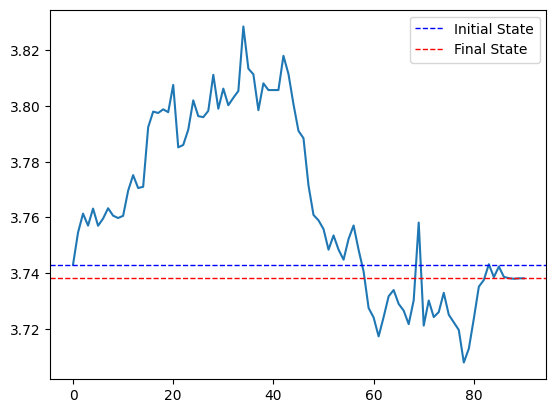

In [11]:
## Here, we extract all geometries.
labels, geoms = output.get_all_geometries()
## This is the evolution of the X coordinate of the first atom along the optimization 
xs = [g[0][0] for g in geoms]

## We plot the evolution of this coordinates, and show that the first step corresponds to the "initial state" coordinates...
## ...and that the last step corresponds to the "final state" 
import matplotlib.pyplot as plt
plt.plot(xs)
plt.axhline(y=initial_state.coord[0][0], color='blue', linestyle='--', linewidth=1, label='Initial State')
plt.axhline(y=final_state.coord[0][0], color='red', linestyle='--', linewidth=1, label='Final State')
plt.legend()
plt.show()

In [12]:
## If multiple computations target the same final state, these keep updating the final state.

## For instance, when multiple optimization computations are necessary:
   ## Computation 1: Reads initial state (coordinates "A"), optimization runs, and last-step coordinates ("B") are used to create the final state.
   ## Computation 2: Reads set of coordinates "B", continues optimization, and last-step coordinates ("C") update the final state.
   ## ... This goes on until the final coordinates are considered good, or the optimization job stops.

## Why are States necessary?

In [13]:
## For two reasons:

In [14]:
# (1) When a computation finishes, the final information may be different than the that of the source. 
# For instance, a geometry optimization might break a bond, so the initial molecule is no longer the same. 

# Thus, if the user wants to get the molecules out of a STATEs coordinates, they need to be re-computed:
new_molec      = final_state.get_moleclist()[0]
# Then, the user can operate with the molecule-class functions regularly

## In most cases, they will be the same as the source
original_molec = source
## Species can be compared based on some compositional criteria (see specie class, function __eq__())
print(original_molec == new_molec)


True


In [15]:
# (2) Because it enables the user to store multiple results of the molecule (e.g. the energy, coordinates) of...
# ... for instance, optimization jobs with different DFT functionals:
found, b3lyp_state = source.find_state("b3lyp_opt")
  
print(final_state.results) # final_state is the result of a pbe optimization
print(b3lyp_state.results)

{'energy': energy: -3158.67305783 au}
{'energy': energy: -3159.62579289 au}


In [16]:
# The b3lyp state is completed after two computations...
print(len(b3lyp_state.computations))

# Associated with two different jobs, with keywords:
for comp in b3lyp_state.computations:
    print(comp._job.keyword)

2
b3lyp_opt
b3lyp_freq


-----------------------------
   Vibrational Normal Mode   
-----------------------------
 Index                  = 1
 Freq (cm-1)            = 21.6469
 IR Intensity (KM/Mole) = 1.0847
 Reduced Mass (AMU)     = 14.2624
 Has Mode               = False



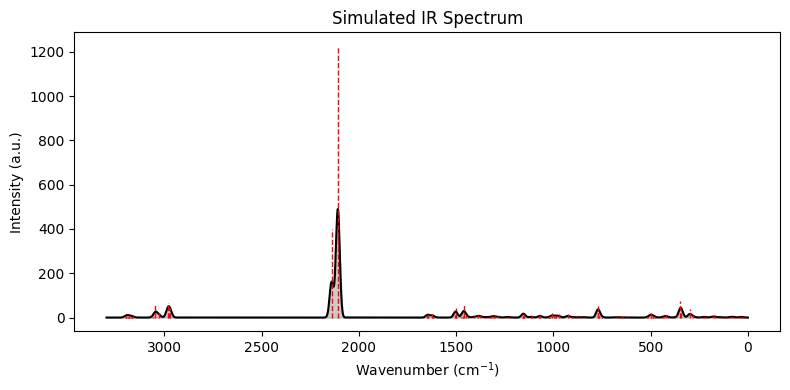

In [17]:
# The second one computes the vibrational normal modes, and stores them:
print(b3lyp_state.VNMs[0])

# And this is the resulting IR spectrum
from Scope.Classes_QC import plot_ir_spectrum
x, spec = plot_ir_spectrum(b3lyp_state.VNMs)